     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


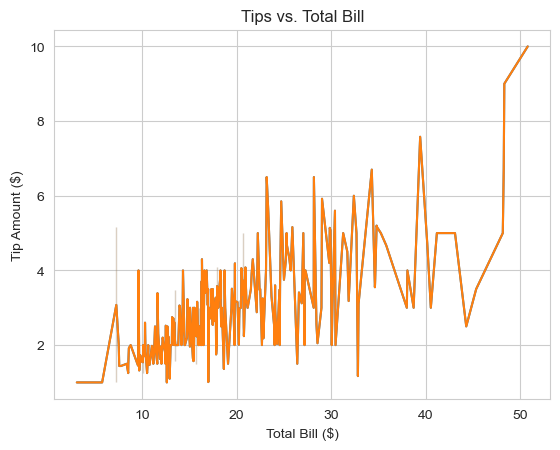

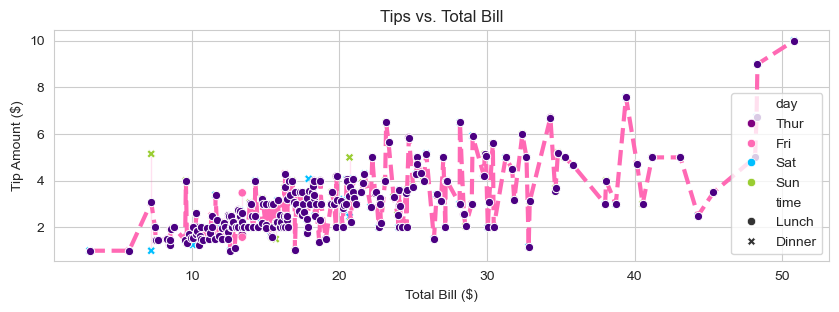

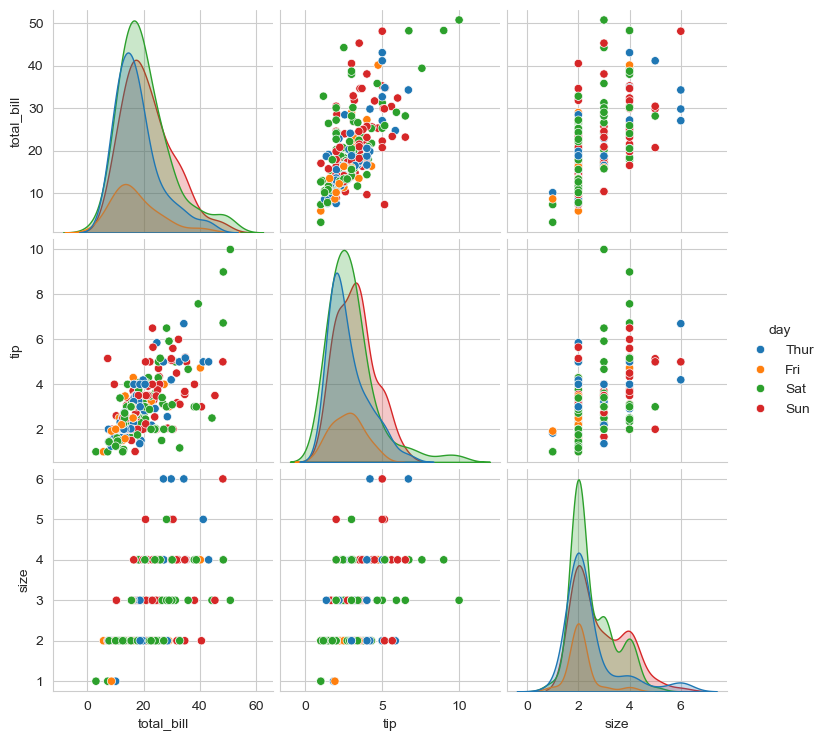

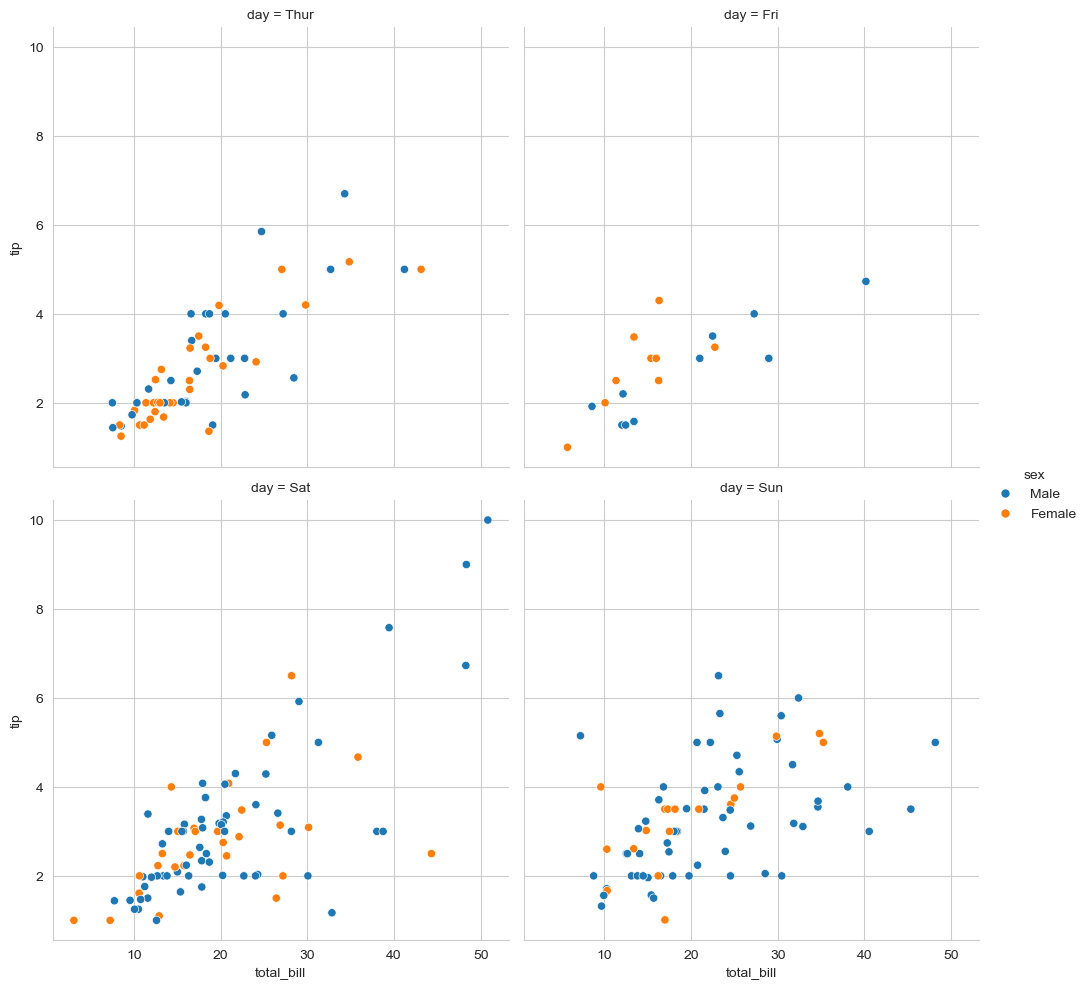

In [5]:
# Install and load packages
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

# Load data
tips = sns.load_dataset("tips")
print(tips)

# Basic plot
sns.lineplot(data=tips, x='total_bill', y='tip')

# Use premade styles
sns.set_style('whitegrid')

# Add title and axis labels
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

# Modify aesthetic elements: figure size
fig = plt.subplots(figsize=(10, 3))

# Modify aesthetic elements: color, line, and marker style
tipgraph = sns.lineplot(
    data=tips,
    x='total_bill',
    y='tip',
    color='hotpink',
    linestyle='--',
    linewidth=3,
    marker='o',
    markerfacecolor='indigo'
)

# Add multiple variables (scatterplot with hue and style)
tipgraph = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    style='time',
    hue='day',
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

# Pairplot
sns.pairplot(data=tips, hue='day')

# Relplot
daysplot = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    col="day",
    kind="scatter",
    col_wrap=2
)

# Plotly setup and simple bar plot
import plotly.graph_objects as go

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score"
)
graph.show()

# Export plotly graph
graph.write_html("pirategraph.html")

# Customizing Plotly graphs
graph = go.Figure()
graph.add_trace(go.Scatter(
    x=x1, y=y1, mode='markers',
    marker=dict(
        size=15,
        color='hotpink',
        opacity=1,
        line=dict(width=5, color='purple')
    )
))
graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500,
    height=500
)
graph.show()



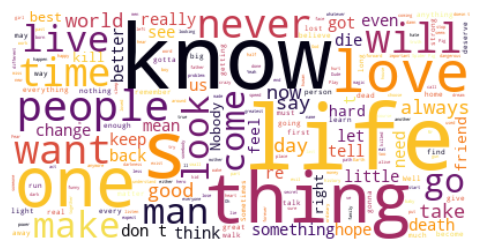

In [3]:
# Wordclouds
from wordcloud import WordCloud

df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip'
)

text = " ".join(each for each in df.quote)

wordcloud = WordCloud(background_color="white", colormap='inferno').generate(text)

fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")
plt.show()



c:\Users\Joanne\miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



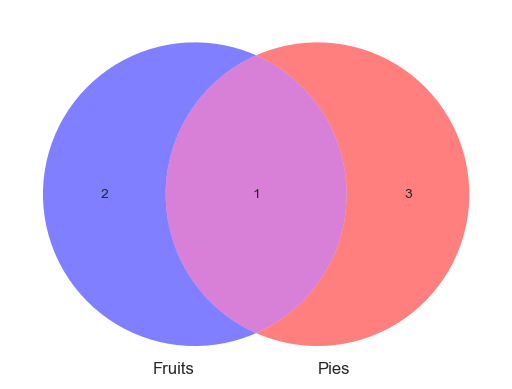

In [2]:
# Venn Diagrams
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=("blue", "red"),
    alpha=0.5
)
plt.show()

# Modify Venn diagram labels
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))
